# Giai đoạn 1 — Mô hình Custom CNN (Model 1) cho Face Anti-Spoofing

Notebook này thực hiện **Giai đoạn 1** của dự án *Hệ thống CNN Học sâu cho Chống giả mạo Khuôn mặt Đa môi trường*:

- Xây dựng một **CNN tự thiết kế từ đầu** (không dùng backbone pretrained) cho bài toán nhị phân Real/Spoof.
- Huấn luyện & đánh giá trên bộ dữ liệu **LCC-FASD**.
- Chạy **local trên Intel iGPU/XPU** thông qua PyTorch XPU backend.
- Tự động tải dữ liệu từ **Kaggle** nếu chưa có sẵn ở `../dataset/`.
- **Hyperparameter tuning bằng Optuna** (Bayesian optimization / TPE) trước khi train full.
- Đánh giá theo chuẩn **ISO/IEC 30107-3** (APCER / BPCER / ACER).
- Lưu checkpoint **Model 1** để dùng làm ứng viên encoder cho Giai đoạn 2 & 3.

> **Giả định đã thống nhất:**
> - Kiến trúc: CNN kiểu VGG-mini / CDCN-lite (cân bằng tốc độ & độ chính xác).
> - Tuning: Optuna (TPE + Median Pruner).
> - Kaggle: đã có `~/.kaggle/kaggle.json` hoặc biến môi trường `KAGGLE_USERNAME` / `KAGGLE_KEY` sẵn sàng, dùng làm phương án dự phòng nếu `../dataset/` chưa có/thiếu dữ liệu.


## 1. Cài đặt môi trường

Cài PyTorch bản **XPU** (Intel iGPU/Arc, không CUDA) theo đúng lệnh bạn đã kiểm tra hoạt động, cộng thêm các thư viện phụ trợ: `optuna` (hyperparameter tuning), `kaggle` (tải dataset dự phòng), `albumentations` + `opencv-python-headless` (augmentation/đọc ảnh nhanh), `scikit-learn`, `matplotlib`, `seaborn`, `tqdm`, `pandas`.

Nếu bạn đã cài các gói này rồi, có thể bỏ qua cell tiếp theo — cell được viết an toàn để chạy lại nhiều lần (idempotent).


In [1]:
%pip install --upgrade pip
%pip install torch==2.14.0 torchvision --index-url https://download.pytorch.org/whl/xpu

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/xpu
Note: you may need to restart the kernel to use updated packages.


## 2. Import thư viện & kiểm tra thiết bị XPU/iGPU

Vì bạn xác nhận XPU/iGPU đã chạy ổn định, cell dưới chỉ **kiểm tra và log thông tin thiết bị** (không cài driver/oneAPI). Nếu vì lý do nào đó XPU không sẵn sàng tại thời điểm chạy, code sẽ tự fallback về CPU và cảnh báo rõ ràng thay vì lỗi ngầm.


In [2]:
import os
import io
import json
import time
import random
import shutil
import zipfile
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score

cv2.setNumThreads(0)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Kiểm tra XPU ---
has_xpu = hasattr(torch, "xpu") and torch.xpu.is_available()
if has_xpu:
    DEVICE = torch.device("xpu")
    n_xpu = torch.xpu.device_count()
    print(f"✅ Đã phát hiện {n_xpu} thiết bị XPU.")
    for i in range(n_xpu):
        try:
            print(f"   - xpu:{i} -> {torch.xpu.get_device_name(i)}")
        except Exception as e:
            print(f"   - xpu:{i} -> (không lấy được tên thiết bị: {e})")
else:
    DEVICE = torch.device("cpu")
    print("⚠️  Không phát hiện XPU khả dụng lúc này -> fallback về CPU.")
    print("    Kiểm tra lại driver Intel GPU / phiên bản torch nếu đây không phải điều bạn mong đợi.")

print(f"\nPyTorch version : {torch.__version__}")
print(f"Thiết bị sử dụng: {DEVICE}")

# bf16 autocast khả dụng tốt trên Intel iGPU/XPU
USE_AMP = False
AUTOCAST_DEVICE_TYPE = "xpu" if has_xpu else "cpu"
AUTOCAST_DTYPE = torch.bfloat16
print(f"Dùng autocast bf16: {USE_AMP}")


/home/dainguyen1506/Documents/face-anti-spoofing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Đã phát hiện 1 thiết bị XPU.
   - xpu:0 -> Intel(R) Graphics

PyTorch version : 2.14.0+xpu
Thiết bị sử dụng: xpu
Dùng autocast bf16: False


## 3. Cấu hình chung

Toàn bộ đường dẫn & hằng số quan trọng được gom vào một chỗ để dễ chỉnh sửa. Mặc định giả sử notebook này nằm trong một thư mục con của repo (ví dụ `notebooks/`), nên dataset ở `../dataset/` theo đúng như bạn mô tả.


In [3]:
# --- Paths ---
PROJECT_ROOT   = Path("..").resolve()
DATASET_ROOT   = PROJECT_ROOT / "dataset"
MODELS_DIR     = PROJECT_ROOT / "models"
ARTIFACTS_DIR  = PROJECT_ROOT / "artifacts" / "stage1"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_DATASET_SLUG = "faber24/lcc-fasd"

# --- Image and training ---
IMG_SIZE      = 192
NUM_CLASSES   = 2          # 0 = spoof, 1 = real
LABEL2IDX     = {"spoof": 0, "real": 1}
IDX2LABEL     = {v: k for k, v in LABEL2IDX.items()}

NUM_WORKERS   = 4
CPU_THREADS   = 14
CACHE_IN_RAM  = False
MAX_CACHE_MB  = 0

torch.set_num_threads(CPU_THREADS)

# Channels-last changes tensor layout only; model math and accuracy are unchanged.
USE_CHANNELS_LAST = has_xpu
PIN_MEMORY = has_xpu
print(f"Channels-last: {USE_CHANNELS_LAST} | pin_memory: {PIN_MEMORY}")

# --- Optuna hyperparameter tuning ---
N_TRIALS         = 10
TUNE_EPOCHS      = 4
TUNE_TIMEOUT_SEC = None      # e.g. 1800 to cap tuning at 30 minutes
RESUME_TUNING    = True      # persist Optuna study to SQLite and resume missing trials
OPTUNA_STUDY_DB  = ARTIFACTS_DIR / "optuna_stage1.db"

# --- Full training ---
FULL_EPOCHS      = 20
EARLY_STOP_PATIENCE = 7
RESUME_FULL_TRAIN   = False   # load latest checkpoint and continue from the next epoch
MODEL1_CKPT_PATH = MODELS_DIR / "model1_custom_cnn.pt"
MODEL1_LATEST_CKPT_PATH = MODELS_DIR / "model1_custom_cnn_latest.pt"

print("Config ready.")
print(f"DATASET_ROOT  = {DATASET_ROOT}")
print(f"MODELS_DIR    = {MODELS_DIR}")
print(f"ARTIFACTS_DIR = {ARTIFACTS_DIR}")
print(f"NUM_WORKERS   = {NUM_WORKERS}")
print(f"CPU_THREADS   = {torch.get_num_threads()}")

Channels-last: True | pin_memory: True
Config ready.
DATASET_ROOT  = /home/dainguyen1506/Documents/face-anti-spoofing/dataset
MODELS_DIR    = /home/dainguyen1506/Documents/face-anti-spoofing/models
ARTIFACTS_DIR = /home/dainguyen1506/Documents/face-anti-spoofing/artifacts/stage1
NUM_WORKERS   = 4
CPU_THREADS   = 14


## 4. Check local LCC-FASD, download from Kaggle if missing

This project uses the local layout `../dataset/LCC_FASD/` with three fixed splits:
- `LCC_FASD_training/real|spoof`
- `LCC_FASD_development/real|spoof`
- `LCC_FASD_evaluation/real|spoof`

If that layout is missing or incomplete, the notebook downloads the dataset from Kaggle and checks the same layout again.


In [4]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def split_dirs_for(root: Path):
    return {
        "train": root / "LCC_FASD_training",
        "val":   root / "LCC_FASD_development",
        "test":  root / "LCC_FASD_evaluation",
    }


def count_images(folder: Path) -> int:
    return sum(1 for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS) if folder.is_dir() else 0


def split_ready(split_dir: Path) -> bool:
    return count_images(split_dir / "real") > 0 and count_images(split_dir / "spoof") > 0


def find_lcc_fasd_root():
    candidates = [DATASET_ROOT / "LCC_FASD", DATASET_ROOT]
    if DATASET_ROOT.exists():
        candidates += [p.parent for p in DATASET_ROOT.rglob("LCC_FASD_training") if p.is_dir()]

    seen = set()
    for root in candidates:
        root = root.resolve()
        if root in seen:
            continue
        seen.add(root)
        split_dirs = split_dirs_for(root)
        if all(split_ready(d) for d in split_dirs.values()):
            return root, split_dirs

    root = (DATASET_ROOT / "LCC_FASD").resolve()
    return root, split_dirs_for(root)


LCC_FASD_ROOT, SPLIT_DIRS = find_lcc_fasd_root()
dataset_ready = all(split_ready(d) for d in SPLIT_DIRS.values())

print(f"LCC_FASD_ROOT = {LCC_FASD_ROOT}")
print(f"Dataset ready : {dataset_ready}")


LCC_FASD_ROOT = /home/dainguyen1506/Documents/face-anti-spoofing/dataset/LCC_FASD
Dataset ready : True


In [5]:
if not dataset_ready:
    print(f"Local LCC-FASD not found at {LCC_FASD_ROOT} -> downloading from Kaggle...")
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    try:
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        api.dataset_download_files(KAGGLE_DATASET_SLUG, path=str(DATASET_ROOT), unzip=True, quiet=False)
        print("Kaggle download finished.")
    except Exception as e:
        raise RuntimeError(
            "Could not download LCC-FASD from Kaggle automatically. "
            "Check ~/.kaggle/kaggle.json or KAGGLE_USERNAME/KAGGLE_KEY, "
            f"or download '{KAGGLE_DATASET_SLUG}' manually into {DATASET_ROOT}. Original error: {e}"
        )

    LCC_FASD_ROOT, SPLIT_DIRS = find_lcc_fasd_root()
    dataset_ready = all(split_ready(d) for d in SPLIT_DIRS.values())

assert dataset_ready, f"LCC-FASD is still missing or incomplete under {DATASET_ROOT}."
print("Using local dataset splits:")
for name, folder in SPLIT_DIRS.items():
    print(f"  {name:5s}: {folder}")


Using local dataset splits:
  train: /home/dainguyen1506/Documents/face-anti-spoofing/dataset/LCC_FASD/LCC_FASD_training
  val  : /home/dainguyen1506/Documents/face-anti-spoofing/dataset/LCC_FASD/LCC_FASD_development
  test : /home/dainguyen1506/Documents/face-anti-spoofing/dataset/LCC_FASD/LCC_FASD_evaluation


## 5. Build train/val/test sample lists

The local LCC-FASD split is already fixed, so this cell only reads images from `real/` and `spoof/` inside each split directory.


In [6]:
def list_samples(split_dir: Path):
    samples = []
    for label_name in ("spoof", "real"):
        label_idx = LABEL2IDX[label_name]
        label_dir = split_dir / label_name
        samples.extend(
            (str(p), label_idx)
            for p in sorted(label_dir.rglob("*"))
            if p.suffix.lower() in IMG_EXTS
        )
    return samples


train_samples = list_samples(SPLIT_DIRS["train"])
val_samples   = list_samples(SPLIT_DIRS["val"])
test_samples  = list_samples(SPLIT_DIRS["test"])


def summarize(name, samples):
    cnt = Counter(label for _, label in samples)
    print(f"{name:5s}: {len(samples):6d} images | real={cnt.get(1, 0):6d} spoof={cnt.get(0, 0):6d}")


print("\n=== Dataset summary ===")
summarize("train", train_samples)
summarize("val",   val_samples)
summarize("test",  test_samples)

assert train_samples and val_samples and test_samples, "One of train/val/test is empty; please check LCC-FASD paths."



=== Dataset summary ===
train:   8299 images | real=  1223 spoof=  7076
val  :   2948 images | real=   405 spoof=  2543
test :   7580 images | real=   314 spoof=  7266


## 6. Dataset & DataLoader

README ghi rõ: *"data loading, không phải compute, là nút thắt chính"*. Để giảm bottleneck này:

1. Dùng `cv2` để decode ảnh (nhanh hơn PIL thuần trong đa số trường hợp).
2. **Cache trong RAM** ảnh đã decode + resize về đúng `IMG_SIZE` ngay từ lần đọc đầu tiên — các epoch sau không phải decode lại từ đĩa. Có ước lượng dung lượng RAM cần thiết và tự tắt cache nếu vượt `MAX_CACHE_MB`.
3. `num_workers` = số CPU core - 1, để tận dụng đa luồng cho phần augmentation còn lại.


In [7]:
# Ước lượng dung lượng RAM cần cho cache (uint8, HWC, IMG_SIZE x IMG_SIZE x 3)
est_bytes_per_img = IMG_SIZE * IMG_SIZE * 3
total_imgs = len(train_samples) + len(val_samples) + len(test_samples)
est_total_mb = est_bytes_per_img * total_imgs / (1024 ** 2)
print(f"Ước lượng RAM cần nếu cache toàn bộ ({total_imgs} ảnh @ {IMG_SIZE}x{IMG_SIZE}): {est_total_mb:.1f} MB")

if CACHE_IN_RAM and MAX_CACHE_MB > 0 and est_total_mb > MAX_CACHE_MB:
    print(f"⚠️ Ước lượng ({est_total_mb:.0f} MB) vượt ngưỡng an toàn ({MAX_CACHE_MB} MB) -> tắt cache RAM.")
    CACHE_IN_RAM = False
else:
    print(f"Cache RAM: {'BẬT' if CACHE_IN_RAM else 'TẮT'}")


class FASDataset(Dataset):
    """Dataset Real/Spoof đọc ảnh, hỗ trợ cache ảnh đã decode và resize."""

    def __init__(self, samples, img_size, transform=None, cache_in_ram=False):
        self.samples = samples
        self.img_size = img_size
        self.transform = transform
        self.cache_in_ram = cache_in_ram
        self._cache = {} if cache_in_ram else None

    def __len__(self):
        return len(self.samples)

    def _decode_and_resize(self, path):
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(
                img,
                (self.img_size, self.img_size),
                interpolation=cv2.INTER_AREA,
            )
        return img

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        if self.cache_in_ram and path in self._cache:
            img = self._cache[path].copy()
        else:
            img = self._decode_and_resize(path)
            if self.cache_in_ram:
                self._cache[path] = img.copy()

        if self.transform is not None:
            img = self.transform(image=img)["image"]

        return img, torch.tensor(label, dtype=torch.long)


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.05,
        rotate_limit=5,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.3,
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.3,
    ),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5)),
        A.ImageCompression(quality_range=(60, 95)),
    ], p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

train_ds = FASDataset(train_samples, IMG_SIZE, train_transform, CACHE_IN_RAM)
val_ds = FASDataset(val_samples, IMG_SIZE, eval_transform, CACHE_IN_RAM)
test_ds = FASDataset(test_samples, IMG_SIZE, eval_transform, CACHE_IN_RAM)

print(f"train_ds={len(train_ds)}  val_ds={len(val_ds)}  test_ds={len(test_ds)}")


Ước lượng RAM cần nếu cache toàn bộ (18827 ảnh @ 192x192): 1985.7 MB
Cache RAM: TẮT
train_ds=8299  val_ds=2948  test_ds=7580


Batch shape: torch.Size([8, 3, 192, 192]) | dtype: torch.float32 | labels: [0, 0, 0, 0, 0, 0, 0, 0]


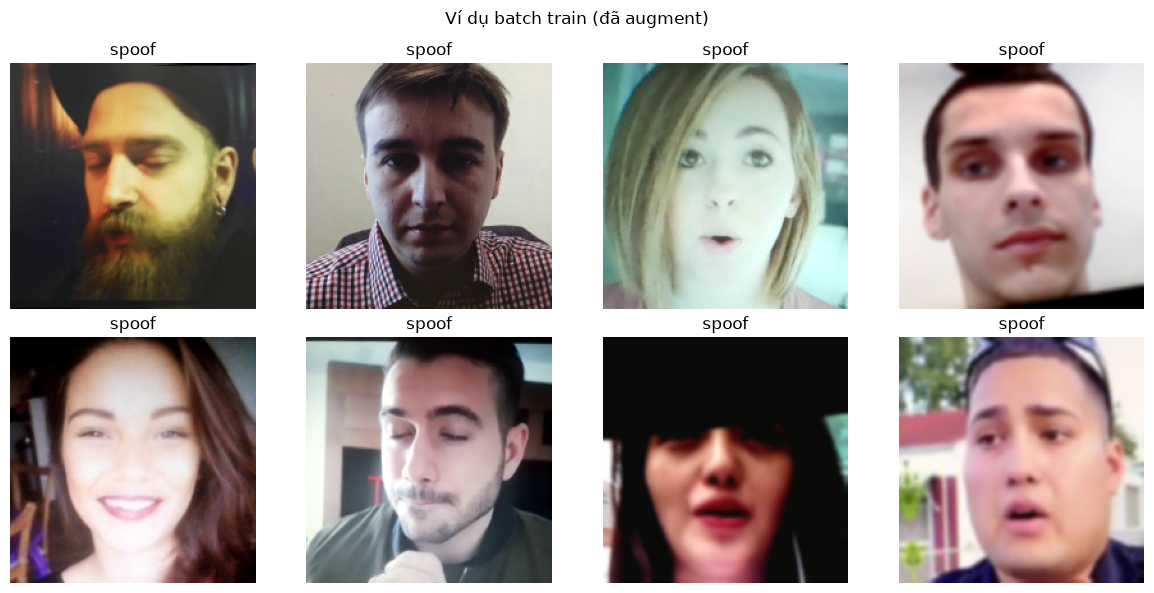

In [8]:
def make_loader(ds, batch_size, shuffle, drop_last=False, num_workers=NUM_WORKERS):
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        drop_last=drop_last,
        pin_memory=PIN_MEMORY,
        persistent_workers=num_workers > 0,
        prefetch_factor=4 if num_workers > 0 else None,
    )

# Xem thử một batch để kiểm tra pipeline hoạt động đúng
_tmp_loader = make_loader(train_ds, batch_size=8, shuffle=True)
_imgs, _labels = next(iter(_tmp_loader))
print("Batch shape:", _imgs.shape, "| dtype:", _imgs.dtype, "| labels:", _labels.tolist())

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
for i, ax in enumerate(axes.flat):
    img = (_imgs[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(IDX2LABEL[_labels[i].item()])
    ax.axis("off")
plt.suptitle("Ví dụ batch train (đã augment)")
plt.tight_layout()
plt.show()

## 7. Kiến trúc CNN tự thiết kế (Model 1)

Theo lựa chọn của bạn — **cân bằng tốc độ & độ chính xác** — thiết kế theo phong cách **VGG-mini / CDCN-lite**:

- 4 block Conv (mỗi block gồm 2 lớp `Conv3x3 → BatchNorm → ReLU`, sau đó `MaxPool2x2`), số kênh tăng dần `base → 2·base → 4·base → 8·base`.
- Không dùng Dense layer khổng lồ ở cuối: **Global Average Pooling** trước FC head để giảm tham số & chống overfitting (dataset FAS thường không quá lớn).
- `Dropout` ở FC head để tăng khả năng tổng quát hóa.
- `base_channels` và `dropout` là **hyperparameter sẽ được Optuna tối ưu**.

Kiến trúc này lấy cảm hứng từ backbone gọn nhẹ trong các paper CDCN (Central Difference Convolutional Network — Yu et al., 2020) nhưng đơn giản hóa (Conv thường thay vì Central-Difference Conv) để phù hợp vai trò "custom baseline" của Giai đoạn 1, tách biệt rõ với Model 2 (pretrained) và Model 3 (multi-task).


In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, 3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, 3, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels, 1,
                    stride=stride, bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


class CustomResNet_FAS(nn.Module):
    """Residual CNN baseline cho face anti-spoofing."""

    def __init__(
        self,
        in_channels=3,
        base_channels=32,
        num_blocks=(2, 2, 2, 2),
        dropout=0.4,
        num_classes=2,
    ):
        super().__init__()
        if len(num_blocks) != 4:
            raise ValueError("num_blocks phải có đúng 4 phần tử")

        self.in_channels = base_channels
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
        )
        self.layer1 = self._make_layer(base_channels, num_blocks[0], 2)
        self.layer2 = self._make_layer(base_channels * 2, num_blocks[1], 2)
        self.layer3 = self._make_layer(base_channels * 4, num_blocks[2], 2)
        self.layer4 = self._make_layer(base_channels * 8, num_blocks[3], 2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(base_channels * 8, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes),
        )

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for current_stride in strides:
            layers.append(
                ResidualBlock(
                    self.in_channels,
                    out_channels,
                    current_stride,
                )
            )
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.classifier(self.gap(x))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


_sanity_model = CustomResNet_FAS(
    base_channels=48,
    num_blocks=(2, 2, 2, 2),
    num_classes=NUM_CLASSES,
)
_sanity_out = _sanity_model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
print("Output shape:", _sanity_out.shape)
print(f"Số tham số: {count_parameters(_sanity_model):,}")
del _sanity_model, _sanity_out


Output shape: torch.Size([2, 2])
Số tham số: 6,386,578


#### Hàm Loss

In [10]:
class FocalLoss(nn.Module):
    """Focal loss với alpha theo class, tính pt từ CE chưa weighted."""

    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)

        if self.alpha is not None:
            alpha_t = self.alpha.to(inputs.device)[targets]
            focal_loss = alpha_t * (1 - pt).pow(self.gamma) * ce_loss
        else:
            focal_loss = (1 - pt).pow(self.gamma) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        if self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss


## 8. Hàm đánh giá theo chuẩn ISO/IEC 30107-3

Quy ước nhãn: `1 = real (bona fide)`, `0 = spoof (attack)`.

- **APCER** = tỉ lệ mẫu **spoof** bị phân loại nhầm thành **real** (rủi ro bị qua mặt hệ thống).
- **BPCER** = tỉ lệ mẫu **real** bị phân loại nhầm thành **spoof** (rủi ro từ chối người dùng thật).
- **ACER** = trung bình cộng của APCER và BPCER — chỉ số tổng thể chính, dùng làm mục tiêu tối ưu cho Optuna & early stopping (thay vì Accuracy thông thường, đúng theo mục 6 của README).


In [11]:
def compute_fas_metrics(y_true, y_pred=None, y_score=None, threshold=0.5):
    y_true = np.asarray(y_true)
    if y_score is not None:
        y_score = np.asarray(y_score)
        y_pred = (y_score >= threshold).astype(np.int64)
    else:
        y_pred = np.asarray(y_pred)

    spoof_mask = y_true == LABEL2IDX["spoof"]
    real_mask = y_true == LABEL2IDX["real"]
    apcer = float(
        (y_pred[spoof_mask] == LABEL2IDX["real"]).mean()
    ) if spoof_mask.any() else 0.0
    bpcer = float(
        (y_pred[real_mask] == LABEL2IDX["spoof"]).mean()
    ) if real_mask.any() else 0.0
    acer = (apcer + bpcer) / 2
    acc = float((y_pred == y_true).mean())

    metrics = {
        "accuracy": acc,
        "APCER": apcer,
        "BPCER": bpcer,
        "ACER": acer,
        "threshold": float(threshold),
    }
    if y_score is not None:
        try:
            metrics["AUC"] = float(roc_auc_score(y_true, y_score))
        except ValueError:
            metrics["AUC"] = float("nan")
    return metrics


def find_best_threshold(y_true, y_score):
    """Find the validation threshold that minimizes ACER."""
    scores = np.asarray(y_score, dtype=np.float64)
    candidates = np.unique(np.concatenate(([0.0, 0.5, 1.0], scores)))
    best_threshold = 0.5
    best_metrics = None

    for threshold in candidates:
        metrics = compute_fas_metrics(
            y_true,
            y_score=scores,
            threshold=float(threshold),
        )
        current_key = (metrics["ACER"], abs(float(threshold) - 0.5))
        best_key = (
            (best_metrics["ACER"], abs(best_threshold - 0.5))
            if best_metrics is not None
            else (float("inf"), float("inf"))
        )
        if current_key < best_key:
            best_threshold = float(threshold)
            best_metrics = metrics

    return best_threshold, best_metrics

## 9. Vòng lặp train / evaluate

Dùng `torch.autocast` (bf16) trên XPU khi khả dụng để tăng tốc mà không cần `GradScaler` (bf16 không cần scale như fp16).


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        if USE_CHANNELS_LAST:
            imgs = imgs.contiguous(memory_format=torch.channels_last)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=AUTOCAST_DEVICE_TYPE,
            dtype=AUTOCAST_DTYPE,
            enabled=USE_AMP,
        ):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss, total = 0.0, 0
    all_true, all_pred, all_score = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        if USE_CHANNELS_LAST:
            imgs = imgs.contiguous(memory_format=torch.channels_last)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(
            device_type=AUTOCAST_DEVICE_TYPE,
            dtype=AUTOCAST_DTYPE,
            enabled=USE_AMP,
        ):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        probs = F.softmax(outputs.float(), dim=1)[:, LABEL2IDX["real"]]
        preds = (probs >= threshold).long()
        running_loss += loss.item() * imgs.size(0)
        total += labels.size(0)
        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())
        all_score.extend(probs.cpu().numpy().tolist())

    metrics = compute_fas_metrics(
        all_true,
        all_pred,
        all_score,
        threshold=threshold,
    )
    metrics["loss"] = running_loss / total
    return metrics, all_true, all_pred, all_score


def make_optimizer(model, name, lr, weight_decay):
    name = name.lower()
    if name == "adam":
        return torch.optim.Adam(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )
    if name == "adamw":
        return torch.optim.AdamW(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )
    if name == "sgd":
        return torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9,
            weight_decay=weight_decay,
            nesterov=True,
        )
    raise ValueError(f"Optimizer không hỗ trợ: {name}")

## 10. Hyperparameter tuning với Optuna

Search space bao gồm: `learning rate`, `weight decay`, `batch size`, `optimizer`, cùng 2 hyperparameter kiến trúc `base_channels` và `dropout`. Mỗi trial chỉ train `TUNE_EPOCHS` epoch ngắn (đủ để so sánh tương đối, không cần hội tụ hoàn toàn), dùng **Median Pruner** để dừng sớm các trial không triển vọng, tiết kiệm thời gian trên máy local.

**Mục tiêu tối ưu: ACER trên tập validation (càng thấp càng tốt)** — nhất quán với chỉ số chính của toàn dự án (mục 6 README), thay vì tối ưu theo Accuracy.


In [13]:
import gc
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.trial import TrialState

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "base_channels": trial.suggest_categorical("base_channels", [32, 48, 64]),
        "n_block1": trial.suggest_int("n_block1", 1, 3),
        "n_block2": trial.suggest_int("n_block2", 1, 4),
        "n_block3": trial.suggest_int("n_block3", 1, 4),
        "n_block4": trial.suggest_int("n_block4", 1, 3),
        "dropout": trial.suggest_float("dropout", 0.2, 0.6),
        "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "gamma": trial.suggest_categorical("gamma", [0.0, 1.0, 2.0, 0.3]),
    }
    num_blocks = tuple(params[f"n_block{i}"] for i in range(1, 5))
    model = CustomResNet_FAS(
        base_channels=params["base_channels"],
        num_blocks=num_blocks,
        dropout=params["dropout"],
        num_classes=NUM_CLASSES,
    ).to(DEVICE)
    if USE_CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)

    count_spoof = sum(label == LABEL2IDX["spoof"] for _, label in train_samples)
    count_real = sum(label == LABEL2IDX["real"] for _, label in train_samples)
    class_weights = torch.tensor(
        [
            len(train_samples) / (2 * count_spoof),
            len(train_samples) / (2 * count_real),
        ],
        dtype=torch.float32,
        device=DEVICE,
    )
    criterion = FocalLoss(alpha=class_weights, gamma=params["gamma"])
    optimizer = make_optimizer(
        model, params["optimizer"], params["lr"], params["weight_decay"]
    )
    workers = NUM_WORKERS
    train_loader = make_loader(
        train_ds, params["batch_size"], shuffle=True,
        drop_last=True, num_workers=workers,
    )
    val_loader = make_loader(
        val_ds, params["batch_size"] * 2, shuffle=False,
        num_workers=workers,
    )

    best_val_acer = float("inf")
    try:
        for epoch in range(TUNE_EPOCHS):
            train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
            _, val_true, _, val_score = evaluate(
                model, val_loader, criterion, DEVICE
            )
            threshold, val_metrics = find_best_threshold(val_true, val_score)
            val_acer = val_metrics["ACER"]
            best_val_acer = min(best_val_acer, val_acer)
            trial.report(val_acer, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
    finally:
        del model, optimizer, criterion, train_loader, val_loader
        gc.collect()
        if has_xpu:
            torch.xpu.empty_cache()

    return best_val_acer


study_kwargs = {
    "direction": "minimize",
    "sampler": TPESampler(seed=SEED),
    "pruner": MedianPruner(n_warmup_steps=2),
    "study_name": "stage1_custom_resnet_fas_v3",
}
if RESUME_TUNING:
    study_kwargs.update({
        "storage": f"sqlite:///{OPTUNA_STUDY_DB.as_posix()}",
        "load_if_exists": True,
    })

study = optuna.create_study(**study_kwargs)
finished_trials = [
    trial for trial in study.trials
    if trial.state in (TrialState.COMPLETE, TrialState.PRUNED, TrialState.FAIL)
]
remaining_trials = max(0, N_TRIALS - len(finished_trials))
print(
    f"Start/resume Optuna tuning: finished {len(finished_trials)}/{N_TRIALS}, "
    f"running {remaining_trials} more ..."
)
t0 = time.time()
if remaining_trials > 0:
    study.optimize(
        objective,
        n_trials=remaining_trials,
        timeout=TUNE_TIMEOUT_SEC,
        show_progress_bar=True,
    )
else:
    print("Saved study already has enough finished trials.")
t1 = time.time()

completed_trials = [
    trial for trial in study.trials if trial.state == TrialState.COMPLETE
]
if not completed_trials:
    raise RuntimeError("Optuna chưa có COMPLETE trial để chọn best_params.")

print(f"\nTuning finished in {(t1 - t0) / 60:.1f} minutes.")
print(f"Trials: {len(study.trials)} (complete: {len(completed_trials)})")
print(f"Best ACER: {study.best_value:.4f}")
print("Best params:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

with open(ARTIFACTS_DIR / "optuna_best_params.json", "w") as file:
    json.dump(study.best_params, file, indent=2, ensure_ascii=False)

Start/resume Optuna tuning: finished 20/10, running 0 more ...
Saved study already has enough finished trials.

Tuning finished in 0.0 minutes.
Trials: 22 (complete: 12)
Best ACER: 0.1212
Best params:
  - base_channels: 32
  - n_block1: 1
  - n_block2: 4
  - n_block3: 3
  - n_block4: 1
  - dropout: 0.22542334011440945
  - lr: 0.0002879775265707035
  - weight_decay: 9.4525713910723e-06
  - batch_size: 64
  - optimizer: adam
  - gamma: 0.3


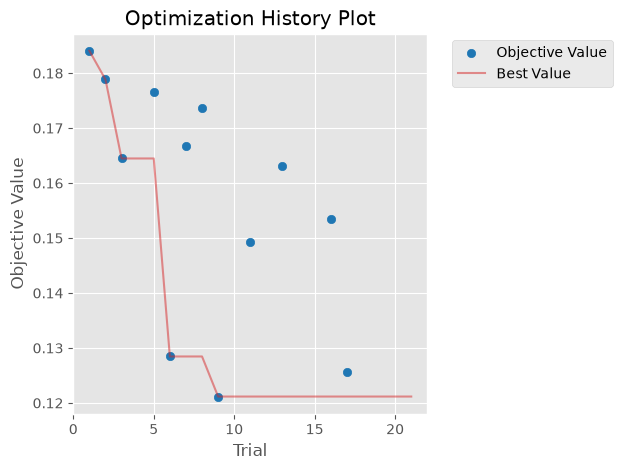

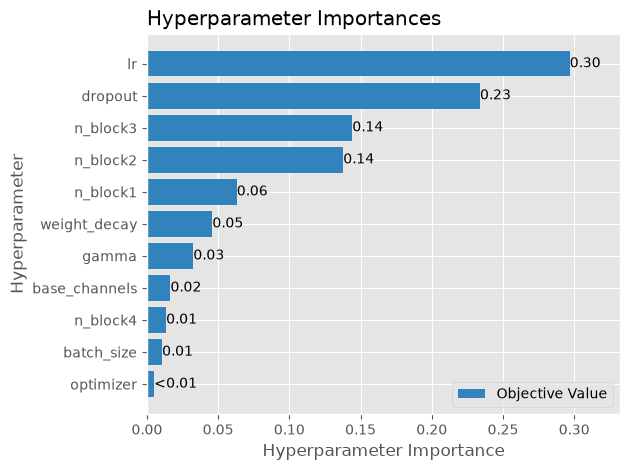

In [14]:
# Trực quan hóa quá trình tuning (matplotlib backend, không cần plotly/kaleido)
try:
    from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
    fig1 = plot_optimization_history(study)
    plt.tight_layout(); plt.show()
    fig2 = plot_param_importances(study)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"Không vẽ được biểu đồ Optuna (không ảnh hưởng kết quả tuning): {e}")


## 11. Full training with the best hyperparameters

Use `study.best_params` to train up to `FULL_EPOCHS` epochs with:
- **Early stopping** by validation ACER (`EARLY_STOP_PATIENCE`).
- **Best checkpoint** at `MODEL1_CKPT_PATH` for the lowest validation ACER.
- **Latest/resume checkpoint** at `MODEL1_LATEST_CKPT_PATH` after every epoch, including model, optimizer, scheduler, history, RNG state, and current epoch. If the notebook or machine stops mid-training, rerun the full-train cell and it will continue from the next epoch.
- **Timing benchmark** to compare with the README estimate of 25-40 minutes / 50 epochs.


In [15]:
best_params = study.best_params
print("Full training with best params:", best_params)

num_blocks = tuple(best_params[f"n_block{i}"] for i in range(1, 5))
workers = NUM_WORKERS
train_loader = make_loader(
    train_ds, best_params["batch_size"], shuffle=True,
    drop_last=True, num_workers=workers,
)
val_loader = make_loader(
    val_ds, best_params["batch_size"] * 2, shuffle=False,
    num_workers=workers,
)

model = CustomResNet_FAS(
    base_channels=best_params["base_channels"],
    num_blocks=num_blocks,
    dropout=best_params["dropout"],
    num_classes=NUM_CLASSES,
).to(DEVICE)
if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

optimizer = make_optimizer(
    model, best_params["optimizer"], best_params["lr"], best_params["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=FULL_EPOCHS
)

count_spoof = sum(label == LABEL2IDX["spoof"] for _, label in train_samples)
count_real = sum(label == LABEL2IDX["real"] for _, label in train_samples)
class_weights = torch.tensor(
    [
        len(train_samples) / (2 * count_spoof),
        len(train_samples) / (2 * count_real),
    ],
    dtype=torch.float32,
    device=DEVICE,
)
criterion = FocalLoss(alpha=class_weights, gamma=best_params["gamma"])

history = defaultdict(list)
best_val_acer = float("inf")
best_epoch = -1
epochs_no_improve = 0
start_epoch = 1

# Training threshold cố định (chỉ dùng 0.5, không tìm random)
TRAIN_THRESHOLD = 0.5

def current_config():
    return {
        "base_channels": best_params["base_channels"],
        "num_blocks": list(num_blocks),
        "dropout": best_params["dropout"],
        "img_size": IMG_SIZE,
        "num_classes": NUM_CLASSES,
        "label2idx": LABEL2IDX,
    }


def checkpoint_matches_current_run(ckpt, params):
    config = ckpt.get("config", {})
    expected_blocks = [params[f"n_block{i}"] for i in range(1, 5)]
    return (
        ckpt.get("hyperparameters") == params
        and config.get("base_channels") == params["base_channels"]
        and config.get("num_blocks") == expected_blocks
        and config.get("dropout") == params["dropout"]
        and config.get("img_size") == IMG_SIZE
        and config.get("num_classes") == NUM_CLASSES
    )


def capture_rng_state():
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
    }
    if has_xpu:
        try:
            state["xpu"] = torch.xpu.get_rng_state_all()
        except Exception:
            pass
    return state


def restore_rng_state(state):
    if not state:
        return
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch_state = torch.as_tensor(
        state["torch"], dtype=torch.uint8, device="cpu"
    ).contiguous()
    torch.set_rng_state(torch_state)
    if has_xpu and "xpu" in state:
        try:
            xpu_states = [
                torch.as_tensor(item, dtype=torch.uint8, device="cpu").contiguous()
                for item in state["xpu"]
            ]
            torch.xpu.set_rng_state_all(xpu_states)
        except Exception as exc:
            print(f"Không khôi phục được XPU RNG state: {exc}")


if RESUME_FULL_TRAIN and MODEL1_LATEST_CKPT_PATH.exists():
    resume_ckpt = torch.load(
        MODEL1_LATEST_CKPT_PATH, map_location=DEVICE, weights_only=False
    )
    if checkpoint_matches_current_run(resume_ckpt, best_params):
        model.load_state_dict(resume_ckpt["model_state_dict"])
        optimizer.load_state_dict(resume_ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(resume_ckpt["scheduler_state_dict"])
        history = defaultdict(list, resume_ckpt.get("history", {}))
        best_val_acer = resume_ckpt.get("best_val_acer", best_val_acer)
        best_epoch = resume_ckpt.get("best_epoch", best_epoch)
        epochs_no_improve = resume_ckpt.get("epochs_no_improve", epochs_no_improve)
        start_epoch = int(resume_ckpt["epoch"]) + 1
        restore_rng_state(resume_ckpt.get("rng_state"))
        print(f"Resuming from epoch {start_epoch}.")
    else:
        print("Latest checkpoint không khớp cấu hình mới -> bỏ qua.")

print(f"\nStart full training: up to {FULL_EPOCHS} epochs on {DEVICE} ...")
print(f"(Training với threshold cố định = {TRAIN_THRESHOLD}, tìm threshold tối ưu sau khi training xong)")
t0 = time.time()
last_epoch_trained = start_epoch - 1

if start_epoch > FULL_EPOCHS or epochs_no_improve >= EARLY_STOP_PATIENCE:
    print("Checkpoint đã đạt đủ số epoch hoặc early stopping -> không train lại.")
else:
    for epoch in range(start_epoch, FULL_EPOCHS + 1):
        epoch_t0 = time.time()
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )
        val_metrics, val_true, _, val_score = evaluate(
            model, val_loader, criterion, DEVICE, threshold=TRAIN_THRESHOLD
        )
        scheduler.step()
        last_epoch_trained = epoch

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_acer"].append(val_metrics["ACER"])
        history["val_apcer"].append(val_metrics["APCER"])
        history["val_bpcer"].append(val_metrics["BPCER"])

        improved = val_metrics["ACER"] < best_val_acer
        if improved:
            best_val_acer = val_metrics["ACER"]
            best_epoch = epoch
            epochs_no_improve = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "config": current_config(),
                "hyperparameters": best_params,
                "val_metrics": val_metrics,
                "epoch": epoch,
            }, MODEL1_CKPT_PATH)
        else:
            epochs_no_improve += 1

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history": dict(history),
            "best_val_acer": best_val_acer,
            "best_epoch": best_epoch,
            "epochs_no_improve": epochs_no_improve,
            "config": current_config(),
            "hyperparameters": best_params,
            "last_val_metrics": val_metrics,
            "epoch": epoch,
            "full_epochs": FULL_EPOCHS,
            "rng_state": capture_rng_state(),
        }, MODEL1_LATEST_CKPT_PATH)

        marker = "  <-- best" if improved else ""
        print(
            f"[{epoch:03d}/{FULL_EPOCHS}] train_loss={train_loss:.4f} "
            f"train_acc={train_acc:.4f} | val_ACER={val_metrics['ACER']:.4f} "
            f"({time.time() - epoch_t0:.1f}s){marker}"
        )
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

total_minutes = (time.time() - t0) / 60
print(
    f"Train done in {total_minutes:.1f} minutes; reached epoch {last_epoch_trained}, "
    f"best epoch={best_epoch}, val ACER={best_val_acer:.4f}."
)

Full training with best params: {'base_channels': 32, 'n_block1': 1, 'n_block2': 4, 'n_block3': 3, 'n_block4': 1, 'dropout': 0.22542334011440945, 'lr': 0.0002879775265707035, 'weight_decay': 9.4525713910723e-06, 'batch_size': 64, 'optimizer': 'adam', 'gamma': 0.3}

Start full training: up to 20 epochs on xpu ...
(Training với threshold cố định = 0.5, tìm threshold tối ưu sau khi training xong)
[001/20] train_loss=0.3959 train_acc=0.7878 | val_ACER=0.1664 (122.8s)  <-- best
[002/20] train_loss=0.3129 train_acc=0.8454 | val_ACER=0.2697 (113.7s)
[003/20] train_loss=0.2636 train_acc=0.8731 | val_ACER=0.2835 (112.4s)
[004/20] train_loss=0.2214 train_acc=0.8939 | val_ACER=0.2718 (112.4s)
[005/20] train_loss=0.1785 train_acc=0.9148 | val_ACER=0.2911 (112.7s)
[006/20] train_loss=0.1776 train_acc=0.9300 | val_ACER=0.2441 (110.9s)
[007/20] train_loss=0.1405 train_acc=0.9403 | val_ACER=0.1943 (111.0s)
[008/20] train_loss=0.1276 train_acc=0.9491 | val_ACER=0.1528 (113.0s)  <-- best
[009/20] train_

## 12. Biểu đồ quá trình huấn luyện

Evaluating best model trên validation set để tìm threshold tối ưu...

=== Threshold tối ưu trên Validation ===
Best threshold: 0.6000
  ACER  : 0.1430
  APCER : 0.1058
  BPCER : 0.1802
  Acc   : 0.8840


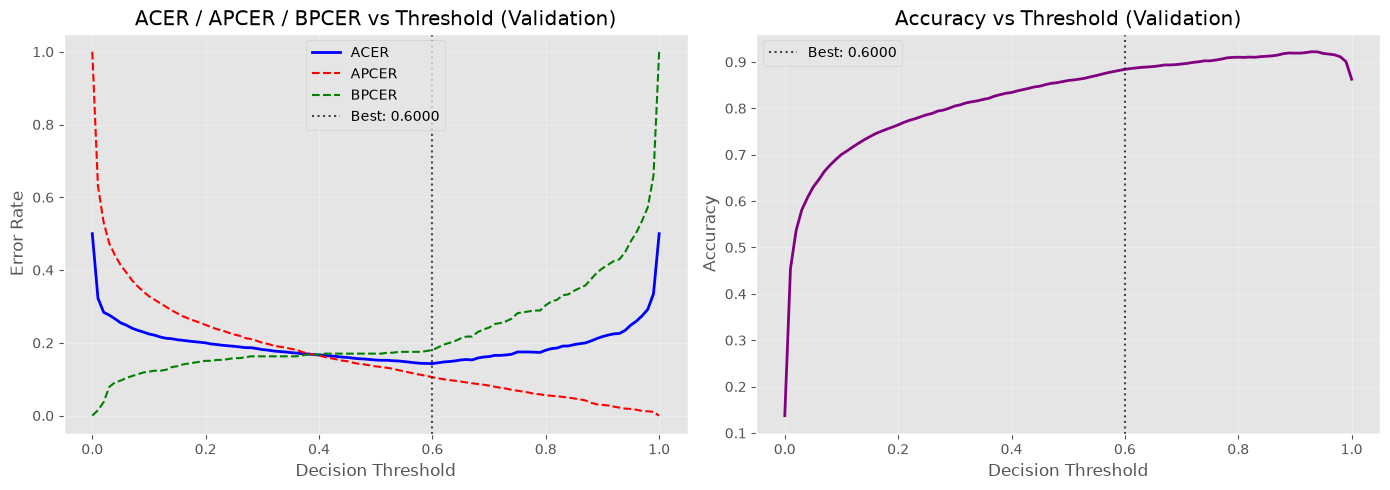


Threshold tuning results saved to threshold_tuning_results.json


In [16]:
## 11b. Tìm threshold tối ưu trên validation (sau training)

# Load checkpoint tốt nhất từ training
best_ckpt = torch.load(
    MODEL1_CKPT_PATH,
    map_location=DEVICE,
    weights_only=False,
)
config = best_ckpt["config"]
best_params = best_ckpt["hyperparameters"]

# Rebuild model và load weights
tuning_model = CustomResNet_FAS(
    base_channels=config["base_channels"],
    num_blocks=tuple(config["num_blocks"]),
    dropout=config["dropout"],
    num_classes=config["num_classes"],
).to(DEVICE)
if USE_CHANNELS_LAST:
    tuning_model = tuning_model.to(memory_format=torch.channels_last)
tuning_model.load_state_dict(best_ckpt["model_state_dict"])

# Evaluate trên validation để lấy predictions
val_loader_for_threshold = make_loader(
    val_ds,
    batch_size=best_params["batch_size"] * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print("Evaluating best model trên validation set để tìm threshold tối ưu...")
_, val_true_for_threshold, _, val_score_for_threshold = evaluate(
    tuning_model,
    val_loader_for_threshold,
    nn.CrossEntropyLoss(),
    DEVICE,
    threshold=0.5,  # threshold này chỉ dùng tạm để get predictions
)

# Thử 100 threshold candidates và tìm cái tốt nhất (minimize ACER)
threshold_candidates = np.linspace(0.0, 1.0, 101)
results_by_threshold = []

for threshold in threshold_candidates:
    metrics = compute_fas_metrics(
        val_true_for_threshold,
        y_score=val_score_for_threshold,
        threshold=float(threshold),
    )
    results_by_threshold.append({
        "threshold": float(threshold),
        "ACER": metrics["ACER"],
        "APCER": metrics["APCER"],
        "BPCER": metrics["BPCER"],
        "accuracy": metrics["accuracy"],
    })

# Tìm threshold với ACER thấp nhất
results_df = pd.DataFrame(results_by_threshold)
best_idx = results_df["ACER"].idxmin()
best_result = results_df.iloc[best_idx]

print("\n=== Threshold tối ưu trên Validation ===")
print(f"Best threshold: {best_result['threshold']:.4f}")
print(f"  ACER  : {best_result['ACER']:.4f}")
print(f"  APCER : {best_result['APCER']:.4f}")
print(f"  BPCER : {best_result['BPCER']:.4f}")
print(f"  Acc   : {best_result['accuracy']:.4f}")

# Vẽ biểu đồ ACER / APCER / BPCER theo threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df["threshold"], results_df["ACER"], "b-", linewidth=2, label="ACER")
axes[0].plot(results_df["threshold"], results_df["APCER"], "r--", linewidth=1.5, label="APCER")
axes[0].plot(results_df["threshold"], results_df["BPCER"], "g--", linewidth=1.5, label="BPCER")
axes[0].axvline(best_result["threshold"], color="black", linestyle=":", alpha=0.7, label=f"Best: {best_result['threshold']:.4f}")
axes[0].set_xlabel("Decision Threshold")
axes[0].set_ylabel("Error Rate")
axes[0].set_title("ACER / APCER / BPCER vs Threshold (Validation)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df["threshold"], results_df["accuracy"], "purple", linewidth=2)
axes[1].axvline(best_result["threshold"], color="black", linestyle=":", alpha=0.7, label=f"Best: {best_result['threshold']:.4f}")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Threshold (Validation)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "threshold_optimization.png", dpi=150)
plt.show()

# Lưu best threshold vào artifacts
threshold_results = {
    "best_threshold": float(best_result["threshold"]),
    "best_ACER": float(best_result["ACER"]),
    "best_APCER": float(best_result["APCER"]),
    "best_BPCER": float(best_result["BPCER"]),
    "best_accuracy": float(best_result["accuracy"]),
    "all_results": results_by_threshold,
}
with open(ARTIFACTS_DIR / "threshold_tuning_results.json", "w") as file:
    json.dump(threshold_results, file, indent=2, ensure_ascii=False)

print("\nThreshold tuning results saved to threshold_tuning_results.json")


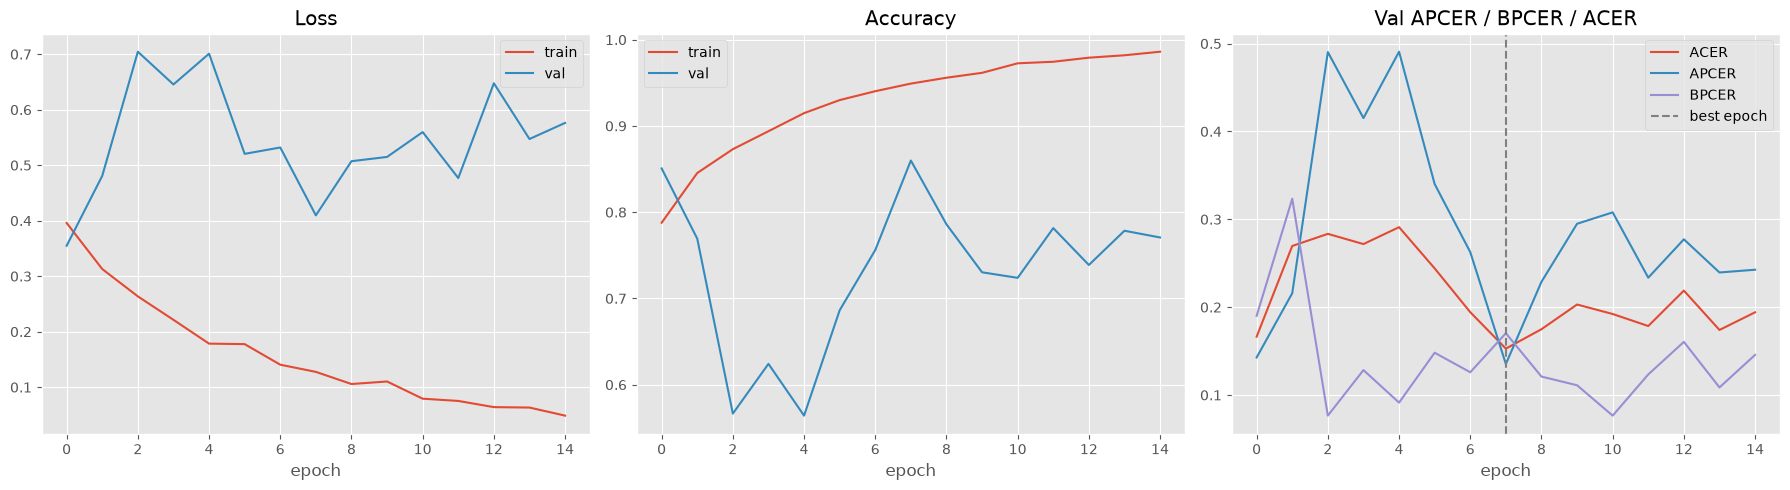

Best epoch: 8, Best val ACER: 0.1528


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

axes[2].plot(history["val_acer"], label="ACER")
axes[2].plot(history["val_apcer"], label="APCER")
axes[2].plot(history["val_bpcer"], label="BPCER")
axes[2].axvline(best_epoch - 1, color="gray", linestyle="--", label="best epoch")
axes[2].set_title("Val APCER / BPCER / ACER"); axes[2].set_xlabel("epoch"); axes[2].legend()

plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / "training_curves.png", dpi=150)
plt.show()

print(f"Best epoch: {best_epoch}, Best val ACER: {best_val_acer:.4f}")


## 13. Đánh giá cuối cùng trên tập test (evaluation split)

Load lại checkpoint **tốt nhất** (theo ACER trên val) rồi đánh giá trên tập test để có con số cuối cùng của **Model 1**. Lưu ý: đây vẫn là test-split *trong* LCC-FASD (cùng domain) — đánh giá **cross-dataset** thực sự với 4 model sẽ thực hiện ở Giai đoạn 5.


Using best threshold from validation: 0.6000

=== Kết quả Model 1 trên tập test (in-domain LCC-FASD) ===
Decision threshold: 0.6000
  accuracy  : 0.9554
  APCER     : 0.0312
  BPCER     : 0.3535
  ACER      : 0.1924
  threshold : 0.6000
  AUC       : 0.9031
  loss      : 0.1509


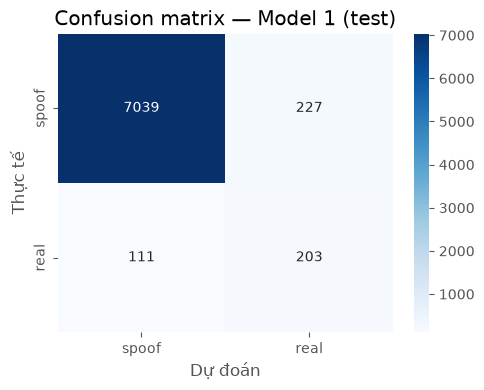


Test results saved to model1_test_metrics.json


In [18]:
## 14. Đánh giá cuối cùng trên tập test (evaluation split) với best threshold

# Load best threshold từ tuning
with open(ARTIFACTS_DIR / "threshold_tuning_results.json", "r") as file:
    threshold_results = json.load(file)
best_threshold_for_test = threshold_results["best_threshold"]

print(f"Using best threshold from validation: {best_threshold_for_test:.4f}")

checkpoint = torch.load(
    MODEL1_CKPT_PATH,
    map_location=DEVICE,
    weights_only=False,
)
config = checkpoint["config"]
best_params = checkpoint["hyperparameters"]

best_model = CustomResNet_FAS(
    base_channels=config["base_channels"],
    num_blocks=tuple(config["num_blocks"]),
    dropout=config["dropout"],
    num_classes=config["num_classes"],
).to(DEVICE)
if USE_CHANNELS_LAST:
    best_model = best_model.to(memory_format=torch.channels_last)
best_model.load_state_dict(checkpoint["model_state_dict"])

test_loader = make_loader(
    test_ds,
    batch_size=best_params["batch_size"] * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

# Evaluate với best threshold
test_metrics, y_true, y_pred, y_score = evaluate(
    best_model,
    test_loader,
    nn.CrossEntropyLoss(),
    DEVICE,
    threshold=best_threshold_for_test,
)

print("\n=== Kết quả Model 1 trên tập test (in-domain LCC-FASD) ===")
print(f"Decision threshold: {best_threshold_for_test:.4f}")
for key, value in test_metrics.items():
    print(f"  {key:10s}: {value:.4f}")

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[LABEL2IDX["spoof"], LABEL2IDX["real"]],
)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["spoof", "real"],
    yticklabels=["spoof", "real"],
)
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title("Confusion matrix — Model 1 (test)")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix_test.png", dpi=150)
plt.show()

# Lưu kết quả test
test_results = {
    "threshold": best_threshold_for_test,
    **test_metrics,
}
with open(ARTIFACTS_DIR / "model1_test_metrics.json", "w") as file:
    json.dump(test_results, file, indent=2, ensure_ascii=False)

print("\nTest results saved to model1_test_metrics.json")


## 14. Stage 1 summary

- **Model 1 (Custom CNN)** is trained from scratch on LCC-FASD, tuned with Optuna, and evaluated with APCER/BPCER/ACER.
- Best checkpoint: `../models/model1_custom_cnn.pt`, with `state_dict`, architecture config, best hyperparameters, and validation metrics at the best epoch.
- Latest checkpoint for resume: `../models/model1_custom_cnn_latest.pt`, with model, optimizer, scheduler, history, RNG state, and the completed epoch. If training is interrupted, rerun the full-train cell to continue from the next epoch.
- Optuna study: `../artifacts/stage1/optuna_stage1.db`, so tuning can also continue missing trials instead of starting over.
- Other artifacts (best Optuna params, training curves, confusion matrix, test metrics) are saved in `../artifacts/stage1/` for reporting.

**Next step (Stage 2):** train and compare pretrained ResNet50 / EfficientNet-B3 / MobileNetV3-Large backbones on the same LCC-FASD setup, then compare against Model 1 to choose the shared backbone for Stage 3.
